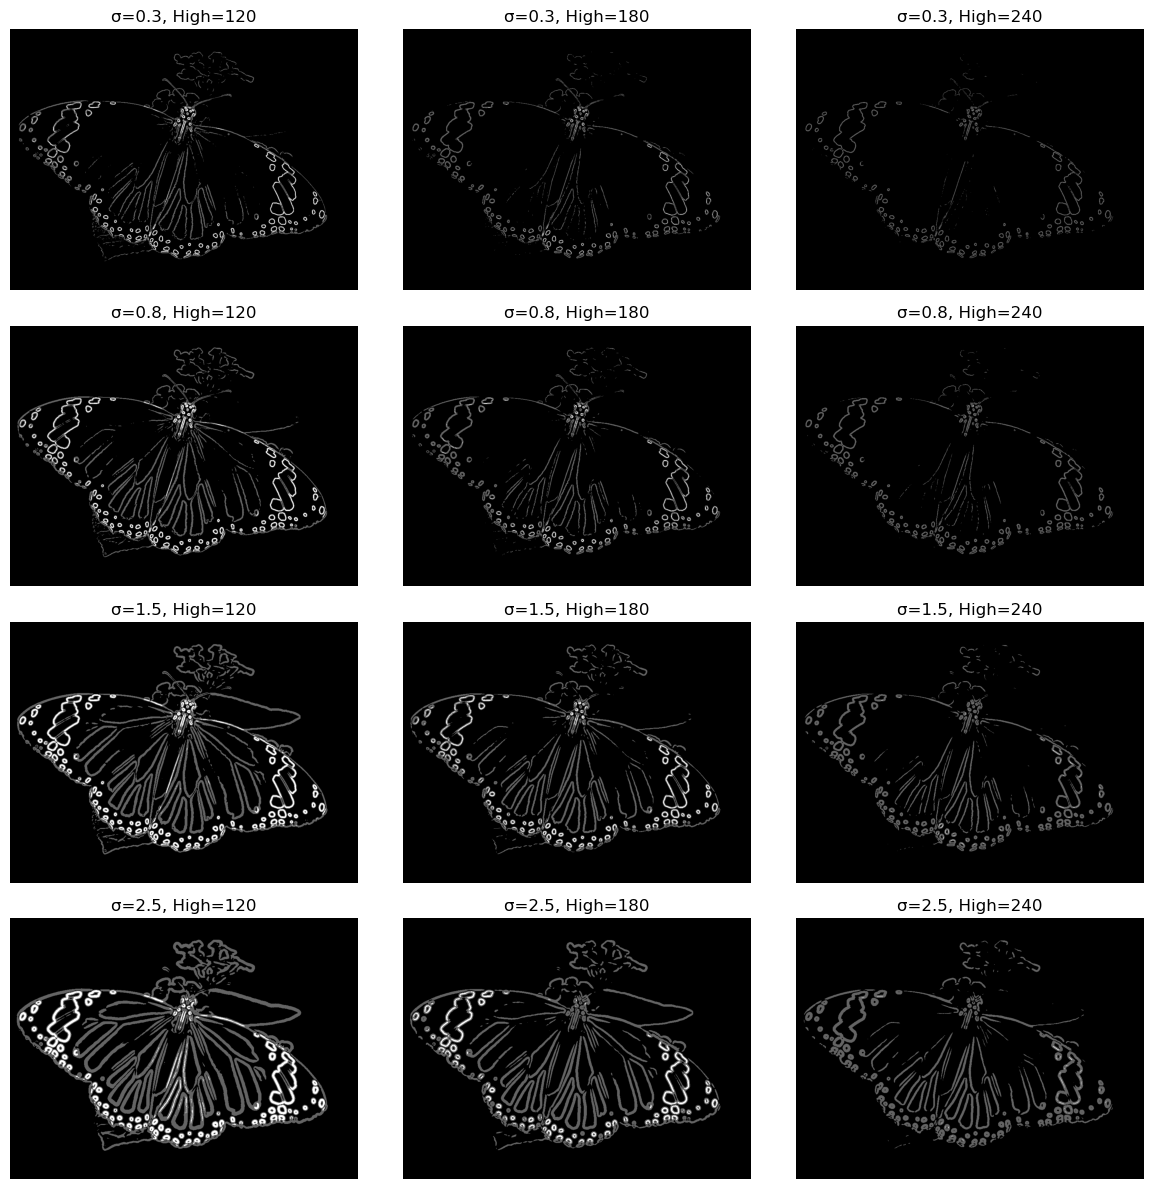

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("tigerbutterfly.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sigmas = [0.3, 0.8, 1.5, 2.5]
high_thresholds = [120, 180, 240]
low_ratio = 0.3

plt.figure(figsize=(12, 12))
plot_no = 1

for sigma in sigmas:
    # Step 1: Gaussian Blur
    ksize = int(6*sigma + 1)
    ksize = max(3, ksize | 1)
    blur = cv2.GaussianBlur(gray, (ksize, ksize), sigma)

    # Step 2: Sobel Gradients
    grad_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)

    # Step 3: Gradient Magnitude
    mag = np.sqrt(grad_x**2 + grad_y**2)
    mag = (mag / mag.max()) * 255
    mag = mag.astype(np.uint8)

    for high in high_thresholds:
        low = int(low_ratio * high)

        # Step 4: Simple Thresholding (instead of full double threshold + hysteresis)
        edges = np.zeros_like(mag)

        strong = mag >= high
        weak = (mag >= low) & (mag < high)

        edges[strong] = 255
        edges[weak] = 100  # just to visualize weak edges

        plt.subplot(len(sigmas), len(high_thresholds), plot_no)
        plt.imshow(edges, cmap='gray')
        plt.title(f"σ={sigma}, High={high}")
        plt.axis('off')

        plot_no += 1

plt.tight_layout()
plt.show()